# MNIST Autoencoder (Fully Connected)

This notebook trains a simple fully-connected autoencoder on MNIST digits:
- Encoder: 784 → 256 → 64 → latent_dim
- Decoder: latent_dim → 64 → 256 → 784

It reconstructs images and visualizes original vs reconstructed samples.

In [1]:
# Setup: imports, device, and seed
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Reproducibility
_ = torch.manual_seed(42)


Using device: cuda


In [65]:
# Model: Fully-connected Autoencoder
class Autoencoder(nn.Module):
    def __init__(self, latent_dim: int = 8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid(),  # outputs in [0,1]
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec.view(-1, 1, 28, 28)

model = Autoencoder(latent_dim=8).to(device)
print(model)


Autoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU(inplace=True)
    (5): Linear(in_features=64, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


In [66]:
# Data: MNIST loaders
transform = transforms.Compose([
    transforms.ToTensor(),  # already scales to [0,1]
])

train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root="./data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

len(train_dataset), len(test_dataset)


(60000, 10000)

In [4]:
# Training
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 5

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, imgs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch}/{num_epochs} - Train MSE: {epoch_loss:.4f}")


Epoch 1/5 - Train MSE: 0.0532
Epoch 2/5 - Train MSE: 0.0294
Epoch 3/5 - Train MSE: 0.0251
Epoch 4/5 - Train MSE: 0.0233
Epoch 5/5 - Train MSE: 0.0221


Test MSE: 0.0212


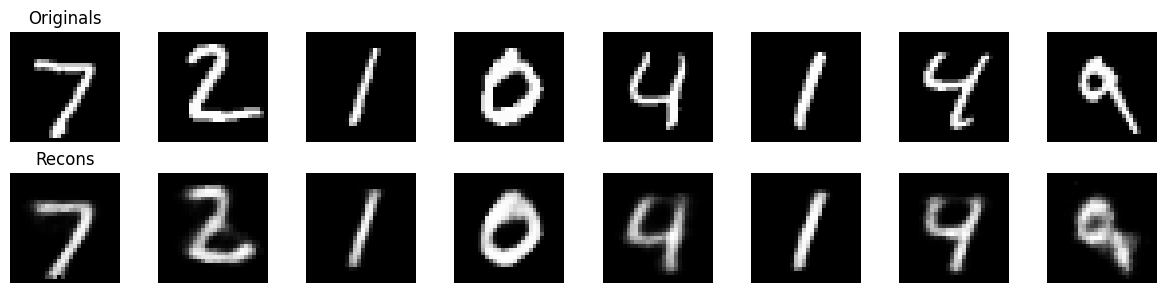

In [5]:
# Evaluation & visualization
model.eval()

# Compute test MSE
test_loss = 0.0
with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        rec = model(imgs)
        loss = criterion(rec, imgs)
        test_loss += loss.item() * imgs.size(0)

test_mse = test_loss / len(test_loader.dataset)
print(f"Test MSE: {test_mse:.4f}")

# Show some reconstructions
n = 8
with torch.no_grad():
    data = next(iter(test_loader))[0][:n].to(device)
    rec = model(data).cpu()

fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))
for i in range(n):
    axes[0, i].imshow(data[i].cpu().squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(rec[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_title("Originals")
axes[1, 0].set_title("Recons")
plt.tight_layout()
plt.show()


In [6]:
# Smoke test: dummy forward pass
model.eval()
with torch.no_grad():
    x = torch.randn(1, 1, 28, 28, device=device)
    y = model(x)
print("Input:", tuple(x.shape), "Output:", tuple(y.shape))

Input: (1, 1, 28, 28) Output: (1, 1, 28, 28)


In [23]:
def num_model_params(model, trainable_only: bool = True) -> int:
    params = model.parameters()
    if trainable_only:
        params = (p for p in params if p.requires_grad)
    return sum(p.numel() for p in params)

print("Trainable params:", num_model_params(model, trainable_only=True))
print("Total params:", num_model_params(model, trainable_only=False))

Trainable params: 436632
Total params: 436632


## Train 100 separate autoencoders

This will sequentially initialize and train multiple fully-connected autoencoders on MNIST and save each checkpoint to disk. A quick-test mode trains only a few models for 1 epoch to validate the flow.

In [7]:
# Utility: train a single autoencoder
from typing import Tuple, List

def train_autoencoder(num_epochs: int = 5, latent_dim: int = 8, lr: float = 1e-3) -> Tuple[Autoencoder, List[float]]:
    model = Autoencoder(latent_dim=latent_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses: List[float] = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running = 0.0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            rec = model(imgs)
            loss = criterion(rec, imgs)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running += loss.item() * imgs.size(0)
        epoch_loss = running / len(train_loader.dataset)
        losses.append(epoch_loss)
    return model, losses


In [8]:
# Driver: train and save multiple autoencoders
import os
from pathlib import Path
import time
save_dir = Path("./meta_gan/checkpoints_autoencoders")
save_dir.mkdir(parents=True, exist_ok=True)


def train_many_autoencoders(n_models: int = 100, num_epochs: int = 5, latent_dim: int = 8, lr: float = 1e-3):
    results = []
    for i in range(n_models):
        curr_time = time.strftime("%Y%m%d-%H%M%S")
        torch.manual_seed(42 + i)  # Make each model initialization deterministic but different
        model, losses = train_autoencoder(num_epochs=num_epochs, latent_dim=latent_dim, lr=lr)
        ckpt_path = save_dir / f"autoencoder_{i:03d}_{curr_time}_{losses[-1]:.4f}.pt"
        torch.save({
            "model_state": model.state_dict(),
            "latent_dim": latent_dim,
            "losses": losses,
        }, ckpt_path)
        print(f"[{i+1}/{n_models}] saved => {ckpt_path} (last loss {losses[-1]:.4f})")
        results.append((ckpt_path, losses[-1]))
    return results

# Quick test: run a tiny batch of models first to validate the loop (change to 100 when ready)
if False:  # set to True to run a quick test
    _ = train_many_autoencoders(n_models=3, num_epochs=1)


In [9]:
# # Run: train 100 autoencoders and save checkpoints
# print("Starting training of 100 autoencoders...")
# results = train_many_autoencoders(n_models=10000, num_epochs=5, latent_dim=8, lr=1e-3)
# print("Training complete. First 5 results:")
# print(results[:5])

In [10]:

import sys
import tqdm


sys.path.append("./meta_gan")  # Ensure we can import our training function

In [11]:
import torch
from torch import nn, optim
from torch.func import stack_module_state, functional_call, vmap
import copy
import time
from pathlib import Path
import math

def train_ensemble_chunk(
    start_idx, n_models_in_chunk, num_epochs, latent_dim, lr, 
    train_loader, save_dir, device
):
    # 1. Initialize N models ensuring different random seeds
    models = []
    for i in range(n_models_in_chunk):
        torch.manual_seed(42 + start_idx + i)
        models.append(Autoencoder(latent_dim=latent_dim))
    
    # 2. Stack parameters into a single vectorized state
    params, buffers = stack_module_state(models)
    
    # 3. Make parameters trainable leaf tensors
    trainable_params = {}
    for k, v in params.items():
        trainable_params[k] = v.to(device).detach().requires_grad_(True)
        
    trainable_buffers = {}
    for k, v in buffers.items():
        trainable_buffers[k] = v.to(device)

    # 4. Define functional forward pass (single model)
    base_model = models[0].to("meta")
    
    def compute_loss(params, buffers, data, target):
        pred = functional_call(base_model, (params, buffers), (data,))
        loss = nn.functional.mse_loss(pred, target, reduction='mean') 
        return loss

    # 5. vmap the compute_loss over the model dimension
    compute_batch_loss = vmap(compute_loss, in_dims=(0, 0, None, None))

    # 6. Create optimizer for the batched parameters
    optimizer = optim.Adam(trainable_params.values(), lr=lr)
    
    # 7. Training Loop
    final_losses = None
    
    for epoch in range(num_epochs):
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            optimizer.zero_grad()
            
            per_model_losses = compute_batch_loss(trainable_params, trainable_buffers, imgs, imgs)
            
            total_loss = per_model_losses.sum()
            total_loss.backward()
            
            optimizer.step()
            
            final_losses = per_model_losses
    
    # 8. Save models
    if final_losses is not None:
        final_losses = final_losses.detach().cpu().tolist()
    else:
        final_losses = [0.0] * n_models_in_chunk

    saved_paths = []
    curr_time = time.strftime("%Y%m%d-%H%M%S")
    keys = list(trainable_params.keys())
    
    # Move everything to CPU for saving
    cpu_params = {k: v.detach().cpu() for k, v in trainable_params.items()}
    cpu_buffers = {k: v.detach().cpu() for k, v in trainable_buffers.items()}
    
    for i in range(n_models_in_chunk):
        model_id = start_idx + i
        loss_val = final_losses[i]
        
        # Reconstruct state dict for this individual model
        # CRITICAL: Use .clone() to ensure we save only this model's data,
        # otherwise PyTorch saves the underlying storage of the entire batch (100x larger)
        single_state_dict = {}
        for k in keys:
             single_state_dict[k] = cpu_params[k][i].clone()
        for k in cpu_buffers:
             single_state_dict[k] = cpu_buffers[k][i].clone()
             
        ckpt_path = save_dir / f"autoencoder_{model_id:03d}_{curr_time}_{loss_val:.4f}.pt"
        torch.save({
            "model_state": single_state_dict,
            "latent_dim": latent_dim,
            "losses": [loss_val] 
        }, ckpt_path)
        saved_paths.append((str(ckpt_path), loss_val))
        
    return saved_paths

def train_many_autoencoders_vmap(n_models=10000, batch_size_models=100, num_epochs=5, latent_dim=8, lr=1e-3):
    """
    Trains n_models in parallel chunks using torch.vmap on GPU.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on {device} using vmap (Vectorized Ensemble Training)")
    print(f"Total models: {n_models} | Chunk size: {batch_size_models} | Epochs: {num_epochs}")
    
    save_dir = Path("./meta_gan/checkpoints_autoencoders")
    save_dir.mkdir(parents=True, exist_ok=True)
    
    all_results = []
    total_start = time.time()
    
    for start_idx in range(0, n_models, batch_size_models):
        current_chunk_size = min(batch_size_models, n_models - start_idx)
        print(f"Processing chunk: models {start_idx} to {start_idx + current_chunk_size - 1}...")
        
        chunk_start = time.time()
        chunk_results = train_ensemble_chunk(
            start_idx, current_chunk_size, num_epochs, latent_dim, lr, 
            train_loader, save_dir, device
        )
        chunk_time = time.time() - chunk_start
        all_results.extend(chunk_results)
        
        print(f"  > Chunk done in {chunk_time:.1f}s. Last Loss (first 3 in chunk): {[round(x[1], 4) for x in chunk_results[:3]]}")
        
        # Force garbage collection
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    elapsed = time.time() - total_start
    print(f"Completed {n_models} models in {elapsed:.2f}s")
    return all_results

In [12]:
# Run the vectorized training
# Batch size reduced to 100 as requested
if __name__ == "__main__":
    results = train_many_autoencoders_vmap(n_models=10000, batch_size_models=3000, num_epochs=5, latent_dim=8, lr=1e-3)

Training on cuda using vmap (Vectorized Ensemble Training)
Total models: 10000 | Chunk size: 3000 | Epochs: 5
Processing chunk: models 0 to 2999...
  > Chunk done in 639.9s. Last Loss (first 3 in chunk): [0.0209, 0.0214, 0.0211]
Processing chunk: models 3000 to 5999...
  > Chunk done in 636.3s. Last Loss (first 3 in chunk): [0.0208, 0.0203, 0.0201]
Processing chunk: models 6000 to 8999...
  > Chunk done in 638.2s. Last Loss (first 3 in chunk): [0.0227, 0.0236, 0.0229]
Processing chunk: models 9000 to 9999...
  > Chunk done in 214.0s. Last Loss (first 3 in chunk): [0.0206, 0.0215, 0.0207]
Completed 10000 models in 2128.36s


Loading checking: autoencoder_2667_20260207-071628_0.0208.pt
Model MSE on test batch: 0.0205


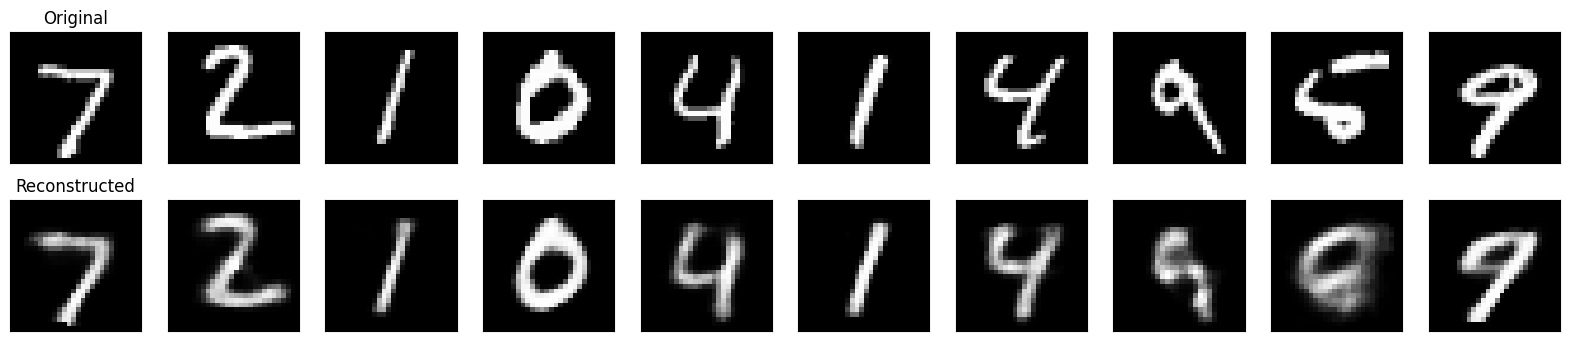

In [36]:
# Sanity Check: Load one random model from disk and visualize reconstruction
import random
import matplotlib.pyplot as plt

# 1. Pick a random saved checkpoint
save_dir = Path("./meta_gan/checkpoints_autoencoders")
all_checkpoints = list(save_dir.glob("*.pt"))

if len(all_checkpoints) == 0:
    print("No checkpoints found! Run the training cell above first.")
else:
    selected_ckpt = random.choice(all_checkpoints)
    print(f"Loading checking: {selected_ckpt.name}")

    # 2. Load state
    checkpoint = torch.load(selected_ckpt)
    
    # 3. Instantiate model
    sanity_model = Autoencoder(latent_dim=checkpoint["latent_dim"]).to(device)
    sanity_model.load_state_dict(checkpoint["model_state"])
    sanity_model.eval()

    # 4. Run inference
    with torch.no_grad():
        # Get one batch from test loader
        test_imgs, _ = next(iter(test_loader))
        test_imgs = test_imgs.to(device)
        
        reconstructions = sanity_model(test_imgs)
        mse = nn.functional.mse_loss(reconstructions, test_imgs).item()
    
    print(f"Model MSE on test batch: {mse:.4f}")

    # 5. Visualize
    n = 10
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(test_imgs[i].cpu().squeeze(), cmap="gray")
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        if i == 0: ax.set_title("Original")

        # Reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructions[i].cpu().squeeze(), cmap="gray")
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        if i == 0: ax.set_title("Reconstructed")
    
    plt.show()

In [13]:
# import torch.multiprocessing as mp
# import tqdm
# from functools import partial

In [14]:
# def main():
#     train_func = partial(train_many_autoencoders, num_epochs=5, latent_dim=32, lr=1e-3)

#     mp.set_start_method('spawn', force=True)  # For compatibility in notebooks

#     with mp.Pool(10) as pool:
#         res = list(tqdm.tqdm(pool.imap(train_func, [1]*10), total=10))
# if __name__ == "__main__":
#     main()

In [15]:
# Aggregate weights: flatten-concat per model and stack across models
from pathlib import Path
import torch

ckpt_dir = Path("./meta_gan/checkpoints_autoencoders")
paths = sorted(ckpt_dir.glob("*.pt"))
print(f"Found {len(paths)} checkpoints in {ckpt_dir}")

rows = []
used_paths = []
param_keys = None
param_shapes = None

for p in paths:
    try:
        payload = torch.load(p, map_location="cpu")
        state = payload.get("model_state", payload)
        # Ensure tensors are on CPU and detached
        state = {k: v.detach().cpu() for k, v in state.items()}
        keys = sorted(state.keys())
        if param_keys is None:
            param_keys = keys
            param_shapes = {k: tuple(state[k].shape) for k in keys}
        else:
            if keys != param_keys:
                print(f"Skipping {p.name}: parameter keys mismatch")
                continue
        vec = torch.cat([state[k].reshape(-1) for k in param_keys], dim=0)
        rows.append(vec)
        used_paths.append(str(p))
    except Exception as e:
        print(f"Skipping {p.name}: {e}")

if not rows:
    print("No valid checkpoints to aggregate.")
    weights_matrix = None
else:
    weights_matrix = torch.stack(rows, dim=0)  # (N, D)
    print(f"weights_matrix shape: {tuple(weights_matrix.shape)} (models, params)")
    out = {
        "weights": weights_matrix,
        "paths": used_paths,
        "param_keys": param_keys,
        "param_shapes": param_shapes,
    }
    torch.save(out, ckpt_dir / "weights_matrix.pt")
    print(f"Saved weights_matrix.pt with {len(used_paths)} models.")


Found 10000 checkpoints in meta_gan/checkpoints_autoencoders
weights_matrix shape: (10000, 436632) (models, params)
Saved weights_matrix.pt with 10000 models.


In [16]:
weights_matrix.shape

torch.Size([10000, 436632])

In [17]:
weights_matrix.var(dim=0)

tensor([0.1439, 0.1435, 0.1433,  ..., 0.0097, 0.0095, 0.0097])

## Weight-space GAN (via PCA)

We model the distribution of trained weight vectors with a small GAN in a low-dimensional PCA space, then map generated coefficients back to full parameter vectors.

In [67]:
# Load/prepare weight vectors and compute PCA basis
import torch
from pathlib import Path

ckpt_dir = Path("./meta_gan/checkpoints_autoencoders")
wm_path = ckpt_dir / "weights_matrix.pt"
if 'weights_matrix' not in globals() or weights_matrix is None:
    bundle = torch.load(wm_path, map_location='cpu')
    weights_matrix = bundle['weights']
    if 'param_keys' in bundle:
        param_keys = bundle['param_keys']
    if 'param_shapes' in bundle:
        param_shapes = bundle['param_shapes']
    print(f"Loaded weights_matrix from file: {tuple(weights_matrix.shape)}")
else:
    print(f"Using in-memory weights_matrix: {tuple(weights_matrix.shape)}")

X = weights_matrix.float()  # (N, D)
mu = X.mean(dim=0, keepdim=True)
Xc = X - mu

K = min(64, X.shape[0] - 1)  # cap PCA rank by number of samples
U, S, V = torch.svd_lowrank(Xc, q=K)
# V has shape (D, K); columns are principal directions
print(f"PCA rank K={K}; shapes U={tuple(U.shape)}, S={tuple(S.shape)}, V={tuple(V.shape)}")


Loaded weights_matrix from file: (10000, 436632)
PCA rank K=64; shapes U=(10000, 64), S=(64,), V=(436632, 64)


In [27]:
# Build training data in PCA space and define a tiny GAN
Z = (Xc @ V)  # (N, K) PCA coefficients

latent_dim = K  # simple choice: same dim as PCA
hidden = 128

class Gen(torch.nn.Module):
    def __init__(self, z_dim=latent_dim, hidden=hidden, out_dim=K):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(z_dim, hidden), torch.nn.ReLU(True),
            torch.nn.Linear(hidden, hidden), torch.nn.ReLU(True),
            torch.nn.Linear(hidden, out_dim),
        )
    def forward(self, x):
        return self.net(x)

class Disc(torch.nn.Module):
    def __init__(self, in_dim=K, hidden=hidden):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(in_dim, hidden), torch.nn.LeakyReLU(0.2, inplace=True),
            torch.nn.Linear(hidden, hidden), torch.nn.LeakyReLU(0.2, inplace=True),
            torch.nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x)

G = Gen().to(device)
D = Disc().to(device)
print(G)
print(D)


Gen(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=128, out_features=64, bias=True)
  )
)
Disc(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [28]:
# Train the GAN on PCA coefficients
import math
from torch.utils.data import TensorDataset, DataLoader

batch_size = 64
dataset = TensorDataset(Z)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

bce = torch.nn.BCEWithLogitsLoss()
optD = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
optG = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))

epochs = 50  # small but enough to fit low-dim distribution

for epoch in range(1, epochs + 1):
    Dl, Gl = 0.0, 0.0
    for (real_z,) in loader:
        real_z = real_z.to(device)
        b = real_z.size(0)
        # Train D
        D.train(); G.train()
        optD.zero_grad()
        logits_real = D(real_z)
        y_real = torch.full((b, 1), 0.9, device=device)  # one-sided label smoothing
        loss_real = bce(logits_real, y_real)

        noise = torch.randn(b, latent_dim, device=device)
        fake_z = G(noise).detach()
        logits_fake = D(fake_z)
        y_fake = torch.zeros(b, 1, device=device)
        loss_fake = bce(logits_fake, y_fake)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optD.step()
        Dl += loss_D.item() * b

        # Train G
        optG.zero_grad()
        noise = torch.randn(b, latent_dim, device=device)
        fake_z = G(noise)
        logits_fake = D(fake_z)
        y_gen = torch.ones(b, 1, device=device)
        loss_G = bce(logits_fake, y_gen)
        loss_G.backward()
        optG.step()
        Gl += loss_G.item() * b
    Dl /= len(dataset); Gl /= len(dataset)
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{epochs} - D: {Dl:.4f}  G: {Gl:.4f}")


Epoch 1/50 - D: 1.2075  G: 0.7607
Epoch 10/50 - D: 1.1459  G: 1.2855
Epoch 20/50 - D: 1.1965  G: 1.0323
Epoch 30/50 - D: 1.1735  G: 1.1260
Epoch 40/50 - D: 1.0868  G: 1.3342
Epoch 50/50 - D: 1.1250  G: 1.3072


In [29]:
# Sample from the GAN and map back to full weight vectors
G.eval()
with torch.no_grad():
    n_gen = 16
    z = torch.randn(n_gen, latent_dim, device=device)
    z_fake = G(z).cpu()
    X_fake = z_fake @ V.T + mu  # map back to full space

print(f"Generated weights shape: {tuple(X_fake.shape)}")

# Save bundle with PCA basis and generated vectors
out = {
    "generated": X_fake,  # (n_gen, D)
    "mu": mu,
    "V": V,
}
torch.save(out, ckpt_dir / "generated_weights_gan.pt")
print("Saved generated_weights_gan.pt")


Generated weights shape: (16, 436632)
Saved generated_weights_gan.pt


## Full-dimensional weight-space WGAN-GP (no PCA)

This trains a GAN directly on full weight vectors (D parameters). To keep models tractable, the generator maps a small latent to the full vector with a single linear layer, and the critic operates on a fixed subvector (random subset of dimensions) with a small MLP. We standardize features by mean/std across models for stability.

In [ ]:
# Data prep: standardize full vectors and define models
import torch
from torch.utils.data import TensorDataset, DataLoader

X_full = weights_matrix.float()  # (N, D)
mu_full = X_full.mean(dim=0, keepdim=True)
sig_full = X_full.std(dim=0, keepdim=True) + 1e-6
X_std = (X_full - mu_full) / sig_full
N, D = X_std.shape
print(f"Full data standardized: N={N}, D={D}")

# Choose a subvector for critic to reduce compute
sub_dim = min(4096, D)
perm = torch.randperm(D)
sub_idx = perm[:sub_dim]

latent_dim_full = 128

class GFull(torch.nn.Module):
    def __init__(self, z=latent_dim_full, out_dim=D):
        super().__init__()
        # Single linear layer to full-D with bias; initialized small
        self.fc = torch.nn.Linear(z, out_dim)
        torch.nn.init.normal_(self.fc.weight, std=0.02)
        torch.nn.init.zeros_(self.fc.bias)
    def forward(self, z):
        return self.fc(z)

class DCritic(torch.nn.Module):
    def __init__(self, in_dim=sub_dim, hidden=512):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(in_dim, hidden), torch.nn.LeakyReLU(0.2, inplace=True),
            torch.nn.Linear(hidden, hidden), torch.nn.LeakyReLU(0.2, inplace=True),
            torch.nn.Linear(hidden, 1),
        )
    def forward(self, x):
        # x is full-D standardized; slice to subvector
        xs = x[..., sub_idx]
        return self.net(xs)

Gf = GFull().to(device)
Cf = DCritic().to(device)
print(Gf)
print(Cf)


In [ ]:
# WGAN-GP training on full standardized vectors
batch_size = 64
loader_full = DataLoader(TensorDataset(X_std), batch_size=batch_size, shuffle=True, drop_last=True)

optC = torch.optim.Adam(Cf.parameters(), lr=1e-4, betas=(0.0, 0.9))
optG = torch.optim.Adam(Gf.parameters(), lr=1e-4, betas=(0.0, 0.9))

lambda_gp = 10.0
critic_iters = 5
epochs_full = 20


def gradient_penalty(C, real, fake):
    b = real.size(0)
    eps = torch.rand(b, 1, device=device)
    eps = eps.expand_as(real)
    inter = eps * real + (1 - eps) * fake
    inter.requires_grad_(True)
    out = C(inter)
    grad = torch.autograd.grad(
        outputs=out,
        inputs=inter,
        grad_outputs=torch.ones_like(out),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    grad = grad.view(b, -1)
    gp = ((grad.norm(2, dim=1) - 1) ** 2).mean()
    return gp

for epoch in range(1, epochs_full + 1):
    Gf.train(); Cf.train()
    g_loss_epoch = 0.0
    c_loss_epoch = 0.0
    for (x_real,) in loader_full:
        x_real = x_real.to(device)
        b = x_real.size(0)
        # Critic updates
        for _ in range(critic_iters):
            z = torch.randn(b, latent_dim_full, device=device)
            x_fake = Gf(z)
            optC.zero_grad()
            c_real = Cf(x_real)
            c_fake = Cf(x_fake.detach())
            gp = gradient_penalty(Cf, x_real, x_fake.detach())
            c_loss = (c_fake.mean() - c_real.mean()) + lambda_gp * gp
            c_loss.backward()
            optC.step()
        c_loss_epoch += c_loss.item() * b

        # Generator update
        z = torch.randn(b, latent_dim_full, device=device)
        x_fake = Gf(z)
        optG.zero_grad()
        g_loss = -Cf(x_fake).mean()
        g_loss.backward()
        optG.step()
        g_loss_epoch += g_loss.item() * b

    c_loss_epoch /= len(loader_full.dataset)
    g_loss_epoch /= len(loader_full.dataset)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{epochs_full} - Critic: {c_loss_epoch:.4f}  Gen: {g_loss_epoch:.4f}")


In [ ]:
# Generate full-D weight vectors and save
Gf.eval()
with torch.no_grad():
    n_gen_full = 16
    z = torch.randn(n_gen_full, latent_dim_full, device=device)
    x_fake_std = Gf(z).cpu()
    X_fake_full = x_fake_std * sig_full + mu_full

print(f"Generated full-D weights shape: {tuple(X_fake_full.shape)}")

full_out = {
    "generated": X_fake_full,  # (n_gen_full, D)
    "mu": mu_full,
    "sigma": sig_full,
    "sub_idx": sub_idx,
}
torch.save(full_out, ckpt_dir / "generated_weights_wgangp.pt")
print("Saved generated_weights_wgangp.pt")


In [ ]:
# WGAN-GP: train until convergence with simple early stopping
import math

# Reuse loader_full, Gf, Cf, mu_full, sig_full defined earlier
assert 'loader_full' in globals() and 'Gf' in globals() and 'Cf' in globals()

optC = torch.optim.Adam(Cf.parameters(), lr=1e-4, betas=(0.0, 0.9))
optG = torch.optim.Adam(Gf.parameters(), lr=1e-4, betas=(0.0, 0.9))

lambda_gp = 10.0
critic_iters = 5
max_epochs = 200
min_epochs = 20
patience = 8
tol_rel = 1e-3


def gradient_penalty(C, real, fake):
    b = real.size(0)
    eps = torch.rand(b, 1, device=device)
    eps = eps.expand_as(real)
    inter = eps * real + (1 - eps) * fake
    inter.requires_grad_(True)
    out = C(inter)
    grad = torch.autograd.grad(
        outputs=out,
        inputs=inter,
        grad_outputs=torch.ones_like(out),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    grad = grad.view(b, -1)
    gp = ((grad.norm(2, dim=1) - 1) ** 2).mean()
    return gp

ema = None
no_improve = 0
for epoch in range(1, max_epochs + 1):
    Gf.train(); Cf.train()
    g_loss_epoch = 0.0
    c_loss_epoch = 0.0
    wdist_epoch = 0.0
    n_batches = 0
    for (x_real,) in loader_full:
        x_real = x_real.to(device)
        b = x_real.size(0)
        # Critic updates
        for _ in range(critic_iters):
            z = torch.randn(b, latent_dim_full, device=device)
            x_fake = Gf(z)
            optC.zero_grad()
            c_real = Cf(x_real)
            c_fake = Cf(x_fake.detach())
            gp = gradient_penalty(Cf, x_real, x_fake.detach())
            c_loss = (c_fake.mean() - c_real.mean()) + lambda_gp * gp
            c_loss.backward()
            optC.step()
        c_loss_epoch += c_loss.item() * b

        # Generator update
        z = torch.randn(b, latent_dim_full, device=device)
        x_fake = Gf(z)
        optG.zero_grad()
        g_loss = -Cf(x_fake).mean()
        g_loss.backward()
        optG.step()
        g_loss_epoch += g_loss.item() * b

        # Track Wasserstein estimate E[D(real)] - E[D(fake)]
        with torch.no_grad():
            wdist_epoch += (c_real.mean() - c_fake.mean()).item() * b
        n_batches += 1

    c_loss_epoch /= len(loader_full.dataset)
    g_loss_epoch /= len(loader_full.dataset)
    wdist_epoch /= len(loader_full.dataset)

    # EMA on absolute Wasserstein distance
    wabs = abs(wdist_epoch)
    ema = wabs if ema is None else 0.9 * ema + 0.1 * wabs

    # Early stopping check after warmup
    stop_msg = ""
    if epoch >= min_epochs:
        # Check relative change vs last epoch's EMA proxy
        # We approximate prev_ema by dividing current ema by 0.9 (rough), good enough for heuristic
        prev_like = ema  # store current and compare next iteration; use no_improve counter
        if 'prev_ema' in globals():
            rel_change = abs(ema - prev_ema) / max(1e-6, abs(prev_ema))
            if rel_change < tol_rel:
                no_improve += 1
            else:
                no_improve = 0
        prev_ema = ema
        if no_improve >= patience:
            stop_msg = f"Early stop at epoch {epoch} (rel_change<{tol_rel} for {patience} epochs)."

    if epoch % 5 == 0 or epoch == 1 or stop_msg:
        print(f"Epoch {epoch}/{max_epochs} - Critic: {c_loss_epoch:.4f}  Gen: {g_loss_epoch:.4f}  |W|_ema: {ema:.6f}")
        if stop_msg:
            print(stop_msg)
            break


In [ ]:
# Build an autoencoder from a generated weight vector and reconstruct an image
assert 'param_keys' in globals() and 'param_shapes' in globals(), "param metadata not found; run aggregation cell first."

# 1) Sample one model from generator
Gf.eval()
with torch.no_grad():
    z = torch.randn(1, latent_dim_full, device=device)
    x_fake_std = Gf(z).cpu()
    vec = x_fake_std * sig_full + mu_full  # (1, D)
vec = vec.squeeze(0)

# 2) Convert flat vector back into a state_dict using param_shapes order
state_gen = {}
off = 0
for k in param_keys:
    shape = param_shapes[k]
    n = 1
    for s in shape:
        n *= s
    chunk = vec[off:off+n].view(shape)
    state_gen[k] = chunk
    off += n
assert off == vec.numel(), "Vector length mismatch while reconstructing state dict."

# 3) Load into a fresh Autoencoder and evaluate on one test image
model_gen = Autoencoder(latent_dim=8).to(device)
missing, unexpected = model_gen.load_state_dict(state_gen, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model_gen.eval()
with torch.no_grad():
    img = next(iter(test_loader))[0][0:1].to(device)  # a single image
    rec = model_gen(img).cpu()

fig, axes = plt.subplots(1, 2, figsize=(4, 2))
axes[0].imshow(img[0].cpu().squeeze(), cmap="gray"); axes[0].set_title("Input"); axes[0].axis('off')
axes[1].imshow(rec[0].squeeze(), cmap="gray"); axes[1].set_title("Recon"); axes[1].axis('off')
plt.tight_layout(); plt.show()


## Weight-space classifier: distinguish trained weights vs random vectors

This section builds a small classifier that, given flattened autoencoder weight vectors ("real") and synthetic random vectors, predicts which is which.

Notes:
- We standardize features using the previously computed per-parameter mean and std (mu_full, sig_full). If missing, we compute them from the real set.
- For negatives, we sample Gaussian random vectors with the same mean/std so the task isn't trivially solved by scale/shift.
- To keep it tractable for very large D, the classifier operates on a fixed random subvector (sub_dim), similar to the WGAN critic earlier.


In [ ]:
# Prep dataset: real trained weight vectors vs random Gaussian negatives (vectorized & memory-safe)
import math
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# Ensure weights_matrix exists
assert 'weights_matrix' in globals(), "weights_matrix not found; run the aggregation cell first."
X_real_cpu = weights_matrix.float().contiguous()  # (N, D) on CPU
N, D = X_real_cpu.shape

# Standardization stats
if 'mu_full' in globals() and 'sig_full' in globals():
    mu_full_cpu = mu_full.detach().cpu().float().view(-1)
    sig_full_cpu = sig_full.detach().cpu().float().clamp_min(1e-6).view(-1)
else:
    mu_full_cpu = X_real_cpu.mean(dim=0).view(-1)
    sig_full_cpu = X_real_cpu.std(dim=0).clamp_min(1e-6).view(-1)

# Choose a subvector for efficiency
sub_dim = min(4096, D)
if 'sub_idx' in globals() and isinstance(sub_idx, torch.Tensor) and sub_idx.numel() == sub_dim:
    sub_idx = sub_idx.detach().cpu().long()
else:
    sub_idx = torch.randperm(D)[:sub_dim]

# Split indices for real samples
val_frac = 0.2
perm = torch.randperm(N)
n_val = max(1, int(N * val_frac))
real_idx_val = perm[:n_val]
real_idx_train = perm[n_val:]

# Precompute standardized real subvectors
X_tr_real_std_sub = ((X_real_cpu[real_idx_train] - mu_full_cpu) / sig_full_cpu)[:, sub_idx]
X_val_real_std_sub = ((X_real_cpu[real_idx_val] - mu_full_cpu) / sig_full_cpu)[:, sub_idx]

# Precompute random negative standardized subvectors
X_tr_neg_std_sub = torch.randn(X_tr_real_std_sub.size(0), sub_dim)
X_val_neg_std_sub = torch.randn(X_val_real_std_sub.size(0), sub_dim)

# Build balanced datasets and shuffle within split
X_tr_sub = torch.cat([X_tr_real_std_sub, X_tr_neg_std_sub], dim=0)
Y_tr = torch.cat([torch.ones(X_tr_real_std_sub.size(0), dtype=torch.long),
                  torch.zeros(X_tr_neg_std_sub.size(0), dtype=torch.long)], dim=0)
perm_tr = torch.randperm(X_tr_sub.size(0))
X_tr_sub = X_tr_sub[perm_tr]
Y_tr = Y_tr[perm_tr]

X_val_sub = torch.cat([X_val_real_std_sub, X_val_neg_std_sub], dim=0)
Y_val = torch.cat([torch.ones(X_val_real_std_sub.size(0), dtype=torch.long),
                   torch.zeros(X_val_neg_std_sub.size(0), dtype=torch.long)], dim=0)
perm_val = torch.randperm(X_val_sub.size(0))
X_val_sub = X_val_sub[perm_val]
Y_val = Y_val[perm_val]

# DataLoaders
batch_size = 256
train_ds = TensorDataset(X_tr_sub, Y_tr)
val_ds = TensorDataset(X_val_sub, Y_val)
train_loader_cls = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader_cls = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)

sub_dim, X_tr_sub.shape, X_val_sub.shape

In [ ]:
# Define a small MLP classifier over the subvector
class WeightDiscriminator(nn.Module):
    def __init__(self, in_dim: int, hidden: int = 1024, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden//2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden//2, 2)
        )
    def forward(self, x):
        return self.net(x)

model_cls = WeightDiscriminator(sub_dim).to(device)
optimizer = torch.optim.AdamW(model_cls.parameters(), lr=3e-4, weight_decay=1e-4)
criterion_cls = nn.CrossEntropyLoss()

best_val_acc = 0.0
patience = 10
no_improve = 0
num_epochs = 50

for epoch in range(1, num_epochs+1):
    model_cls.train()
    total_loss = 0.0
    total_correct = 0
    total = 0
    for xb, yb in train_loader_cls:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model_cls(xb)
        loss = criterion_cls(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total += xb.size(0)
    train_loss = total_loss / total
    train_acc = total_correct / total

    # Validation
    model_cls.eval()
    v_loss = 0.0
    v_correct = 0
    v_total = 0
    with torch.no_grad():
        for xb, yb in val_loader_cls:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model_cls(xb)
            loss = criterion_cls(logits, yb)
            v_loss += loss.item() * xb.size(0)
            v_correct += (logits.argmax(dim=1) == yb).sum().item()
            v_total += xb.size(0)
    val_loss = v_loss / v_total
    val_acc = v_correct / v_total

    print(f"Epoch {epoch:03d}/{num_epochs} - train_loss {train_loss:.4f} acc {train_acc:.3f} | val_loss {val_loss:.4f} acc {val_acc:.3f}")

    if val_acc > best_val_acc + 1e-4:
        best_val_acc = val_acc
        best_state = {k: v.detach().clone() for k, v in model_cls.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stop at epoch {epoch} (no val acc improvement for {patience} epochs).")
            break

# Load best
if 'best_state' in locals():
    model_cls.load_state_dict(best_state)
print(f"Best val acc: {best_val_acc:.3f}")

In [ ]:
# Evaluate on validation set without sklearn and save artifacts
model_cls.eval()
all_true = []
all_pred = []
with torch.no_grad():
    for xb, yb in val_loader_cls:
        logits = model_cls(xb.to(device))
        preds = logits.argmax(dim=1).detach().cpu()
        all_pred.append(preds)
        all_true.append(yb.detach().cpu())

y_true = torch.cat(all_true)
y_pred = torch.cat(all_pred)
acc_val = (y_true == y_pred).float().mean().item()
print(f"Validation accuracy: {acc_val:.3f}")

# Confusion matrix (2x2)
idx = y_true.to(torch.int64) * 2 + y_pred.to(torch.int64)
counts = torch.bincount(idx, minlength=4)
cm = counts.view(2, 2)
print("Confusion matrix (rows=true [0=random,1=real], cols=pred):\n", cm.numpy())

# Save classifier
cls_out = {
    'state_dict': {k: v.detach().cpu() for k, v in model_cls.state_dict().items()},
    'sub_idx': sub_idx.detach().cpu(),
    'mu_full': mu_full_cpu,  # CPU tensors
    'sig_full': sig_full_cpu,
    'input_dim': sub_dim,
}
torch.save(cls_out, ckpt_dir / 'weight_classifier.pt')
print("Saved classifier to:", ckpt_dir / 'weight_classifier.pt')

## Full-dimensional weight classifier (patch Transformer)

We train a classifier on the entire flattened weight vector. To manage memory and parameters, we tokenize the 1D vector into fixed-size patches, embed with a Conv1d, process with a lightweight Transformer encoder, then pool and classify.

In [ ]:
# Build full-dimensional dataset (no subvector)
import torch
from torch.utils.data import TensorDataset, DataLoader

assert 'weights_matrix' in globals(), 'weights_matrix not found.'
X_real = weights_matrix.float()  # CPU (N, D)
N, D = X_real.shape

# Stats
if 'mu_full' in globals() and 'sig_full' in globals():
    mu_full_cpu = mu_full.detach().cpu().float().view(-1)
    sig_full_cpu = sig_full.detach().cpu().float().clamp_min(1e-6).view(-1)
else:
    mu_full_cpu = X_real.mean(dim=0).view(-1)
    sig_full_cpu = X_real.std(dim=0).clamp_min(1e-6).view(-1)

# Standardize reals
X_real_std = (X_real - mu_full_cpu) / sig_full_cpu

# Matched random negatives
X_neg_std = torch.randn_like(X_real_std)

# Split
val_frac = 0.2
perm = torch.randperm(N)
n_val = max(1, int(N * val_frac))
idx_val = perm[:n_val]
idx_tr = perm[n_val:]

X_tr = torch.cat([X_real_std[idx_tr], X_neg_std[idx_tr]], dim=0)
Y_tr = torch.cat([torch.ones(idx_tr.numel(), dtype=torch.long), torch.zeros(idx_tr.numel(), dtype=torch.long)])
X_val = torch.cat([X_real_std[idx_val], X_neg_std[idx_val]], dim=0)
Y_val = torch.cat([torch.ones(idx_val.numel(), dtype=torch.long), torch.zeros(idx_val.numel(), dtype=torch.long)])

perm_tr = torch.randperm(X_tr.size(0))
X_tr = X_tr[perm_tr]; Y_tr = Y_tr[perm_tr]
perm_val = torch.randperm(X_val.size(0))
X_val = X_val[perm_val]; Y_val = Y_val[perm_val]

batch_size_fd = 64
train_ds_fd = TensorDataset(X_tr, Y_tr)
val_ds_fd = TensorDataset(X_val, Y_val)
train_loader_fd = DataLoader(train_ds_fd, batch_size=batch_size_fd, shuffle=True, num_workers=0, pin_memory=True, persistent_workers=True)
val_loader_fd = DataLoader(val_ds_fd, batch_size=batch_size_fd, shuffle=False, num_workers=0, pin_memory=True, persistent_workers=True)

D, X_tr.shape, X_val.shape

In [ ]:
# Streaming full-dimensional dataset (balanced real vs random) to avoid huge tensors
import torch
from torch.utils.data import Dataset, DataLoader

class BalancedFullDimDataset(Dataset):
    def __init__(self, X_real_cpu: torch.Tensor, mu_cpu: torch.Tensor, sig_cpu: torch.Tensor, real_indices: torch.Tensor):
        self.X = X_real_cpu  # (N,D) CPU
        self.mu = mu_cpu.view(-1)
        self.sig = sig_cpu.view(-1)
        self.real_idx = real_indices.view(-1).long()
        self.n_real = self.real_idx.numel()
        self.n_total = self.n_real * 2
    def __len__(self):
        return self.n_total
    def __getitem__(self, idx):
        if idx < self.n_real:
            i = self.real_idx[idx].item()
            x = (self.X[i] - self.mu) / self.sig
            y = 1
        else:
            x = torch.randn_like(self.mu)
            y = 0
        return x, torch.tensor(y, dtype=torch.long)

# Build train/val streaming datasets using the same split as before
N = weights_matrix.shape[0]
perm_fd = torch.randperm(N)
n_val_fd = max(1, int(N*0.2))
idx_val_fd = perm_fd[:n_val_fd]
idx_tr_fd = perm_fd[n_val_fd:]

X_cpu = weights_matrix.float().contiguous()
mu_cpu = mu_full.detach().cpu().float() if 'mu_full' in globals() else X_cpu.mean(dim=0)
sig_cpu = (sig_full.detach().cpu().float().clamp_min(1e-6) if 'sig_full' in globals() else X_cpu.std(dim=0).clamp_min(1e-6))

train_ds_stream = BalancedFullDimDataset(X_cpu, mu_cpu, sig_cpu, idx_tr_fd)
val_ds_stream = BalancedFullDimDataset(X_cpu, mu_cpu, sig_cpu, idx_val_fd)

batch_size_fd = 8
pin = (device.type == 'cuda')
train_loader_fd = DataLoader(train_ds_stream, batch_size=batch_size_fd, shuffle=True, num_workers=0, pin_memory=pin)
val_loader_fd = DataLoader(val_ds_stream, batch_size=batch_size_fd, shuffle=False, num_workers=0, pin_memory=pin)

len(train_ds_stream), len(val_ds_stream), batch_size_fd

In [ ]:
# Patch-Transformer classifier for 1D weight vectors
import math
import torch
from torch import nn
from torch.cuda.amp import autocast, GradScaler

class PatchEmbed1D(nn.Module):
    def __init__(self, in_chans=1, embed_dim=128, patch_size=256):
        super().__init__()
        self.proj = nn.Conv1d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
    def forward(self, x):  # x: (B, D)
        x = x.unsqueeze(1)  # (B,1,D)
        x = self.proj(x)    # (B,embed_dim, num_patches)
        x = x.transpose(1,2)  # (B,num_patches,embed_dim)
        return x

class TransformerClassifier1D(nn.Module):
    def __init__(self, dim, num_patches, n_classes=2, depth=3, nhead=8, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(d_model=dim, nhead=nhead, dim_feedforward=int(dim*mlp_ratio), dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.cls = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, n_classes))
        self.pos = nn.Parameter(torch.zeros(1, num_patches, dim))
    def forward(self, x):  # x: (B,num_patches,dim)
        x = x + self.pos
        x = self.encoder(x)
        x = x.mean(dim=1)
        return self.cls(x)

class FullDimClassifier(nn.Module):
    def __init__(self, D, patch_size=256, embed_dim=128, depth=3, nhead=8):
        super().__init__()
        assert D % patch_size == 0, f"D={D} must be divisible by patch_size={patch_size}"
        self.patch_size = patch_size
        self.num_patches = D // patch_size
        self.embed = PatchEmbed1D(1, embed_dim, patch_size)
        self.backbone = TransformerClassifier1D(embed_dim, self.num_patches, n_classes=2, depth=depth, nhead=nhead)
    def forward(self, x):
        z = self.embed(x)
        logits = self.backbone(z)
        return logits

# Hyperparameters for speed/fit
patch_size = 256
# Crop D to be divisible by patch_size if needed
if D % patch_size != 0:
    crop = D - (D // patch_size) * patch_size
    if crop > 0:
        # Rebuild streaming datasets with cropped features on-the-fly by slicing in forward
        pass

embed_dim = 128
depth = 3
nhead = 8

model_fd = FullDimClassifier(D - (D % patch_size), patch_size=patch_size, embed_dim=embed_dim, depth=depth, nhead=nhead).to(device)
opt_fd = torch.optim.AdamW(model_fd.parameters(), lr=2e-4, weight_decay=1e-4)
crit_fd = nn.CrossEntropyLoss()
scaler = GradScaler(enabled=(device.type=='cuda'))

best_val = 0.0
patience = 5
no_imp = 0
max_epochs = 10

def crop_input(x):
    Dc = model_fd.patch_size * model_fd.num_patches
    if x.shape[1] != Dc:
        return x[:, :Dc]
    return x

for epoch in range(1, max_epochs+1):
    model_fd.train()
    tot_loss = 0.0; tot = 0; corr = 0
    for xb, yb in train_loader_fd:
        xb = crop_input(xb).to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        opt_fd.zero_grad(set_to_none=True)
        with autocast(enabled=(device.type=='cuda')):
            logits = model_fd(xb)
            loss = crit_fd(logits, yb)
        scaler.scale(loss).backward()
        scaler.unscale_(opt_fd)
        torch.nn.utils.clip_grad_norm_(model_fd.parameters(), 1.0)
        scaler.step(opt_fd)
        scaler.update()
        tot_loss += loss.item()*xb.size(0)
        corr += (logits.argmax(1)==yb).sum().item()
        tot += xb.size(0)
    tr_loss = tot_loss/tot; tr_acc = corr/tot

    model_fd.eval(); v_tot=0; v_corr=0; v_loss=0.0
    with torch.no_grad(), autocast(enabled=(device.type=='cuda')):
        for xb, yb in val_loader_fd:
            xb = crop_input(xb).to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            logits = model_fd(xb)
            loss = crit_fd(logits, yb)
            v_loss += loss.item()*xb.size(0)
            v_corr += (logits.argmax(1)==yb).sum().item()
            v_tot += xb.size(0)
    val_loss = v_loss/v_tot; val_acc = v_corr/v_tot
    print(f"[FD] Epoch {epoch:02d}/{max_epochs} - train {tr_loss:.4f}/{tr_acc:.3f} | val {val_loss:.4f}/{val_acc:.3f}")

    if val_acc > best_val + 1e-4:
        best_val = val_acc
        best_fd = {k: v.detach().clone() for k,v in model_fd.state_dict().items()}
        no_imp = 0
    else:
        no_imp += 1
        if no_imp >= patience:
            print(f"[FD] Early stop at epoch {epoch}")
            break

if 'best_fd' in locals():
    model_fd.load_state_dict(best_fd)
print(f"[FD] Best val acc: {best_val:.3f}")

# Save
fd_out = {
    'state_dict': {k: v.detach().cpu() for k,v in model_fd.state_dict().items()},
    'D': model_fd.patch_size * model_fd.num_patches,
    'patch_size': patch_size,
    'embed_dim': embed_dim,
}
torch.save(fd_out, ckpt_dir / 'weight_classifier_full_dim.pt')
print('Saved full-dim classifier to:', ckpt_dir / 'weight_classifier_full_dim.pt')

## Patch-based full-dimensional WGAN-GP for weight vectors

We train a GAN that outputs full-size standardized weight vectors (length D). The generator produces patch tokens and reconstructs the 1D vector via a ConvTranspose1d patch decoder; the critic embeds patches and scores with a lightweight 1D CNN over tokens. Training uses WGAN-GP for stability.

In [31]:
weights_matrix.shape

torch.Size([10000, 436632])

In [68]:
# Dataset prep for WGAN-GP on full-dimensional standardized vectors
import torch
from torch.utils.data import DataLoader, TensorDataset

assert 'weights_matrix' in globals(), 'weights_matrix not found.'
X_real = weights_matrix.float()
N, D = X_real.shape

# Standardize
if 'mu_full' in globals() and 'sig_full' in globals():
    mu_fd = mu_full.detach().cpu().float().view(-1)
    sig_fd = sig_full.detach().cpu().float().clamp_min(1e-6).view(-1)
else:
    mu_fd = X_real.mean(dim=0).view(-1)
    sig_fd = X_real.std(dim=0).clamp_min(1e-6).view(-1)

X_std_full = (X_real - mu_fd) / sig_fd

# Ensure D divisible by patch_size
patch_size = 256
Dc = (D // patch_size) * patch_size
if Dc != D:
    X_std_full = X_std_full[:, :Dc]
    D = Dc

batch_size_gan = 64
loader_fd = DataLoader(TensorDataset(X_std_full), batch_size=batch_size_gan, shuffle=True) 


In [10]:
# Layer 1 GAN: Treating weights as a Matrix (Set of Neurons)
# Sequence Length = 256 (Neurons), Feature Dim = 785 (784 weights + 1 bias)
import torch
from torch import nn, optim
import math
import gc

# 1. Cleaning & Data Prep
torch.cuda.empty_cache()
gc.collect()

if 'weights_matrix' not in globals():
    # Fallback load
    from pathlib import Path
    ckpt_dir = Path("./meta_gan/checkpoints_autoencoders")
    wm_path = ckpt_dir / "weights_matrix.pt"
    if wm_path.exists():
        bundle = torch.load(wm_path, map_location='cpu')
        weights_matrix = bundle['weights']
        param_keys = bundle['param_keys']
        param_shapes = bundle['param_shapes']
        print("Loaded weights_matrix from disk.")
    else:
        raise ValueError("weights_matrix not found")

# Identify keys for Layer 1
layer1_keys = [k for k in param_keys if 'encoder.1' in k]
print(f"Targeting Layer 1 keys: {layer1_keys}")

# Reconstruct Layer 1
# 'encoder.1.weight' -> (256, 784)
# 'encoder.1.bias'   -> (256)
# We want to stack them to (256, 785)
# Need to fetch them separately and stack
current_idx = 0
w_start, w_end = -1, -1
b_start, b_end = -1, -1

# Scan offsets
for k in param_keys:
    shape = tuple(int(s) for s in param_shapes[k])
    numel = int(torch.tensor(shape).prod().item())
    
    if k == 'encoder.1.weight':
        w_start, w_end = current_idx, current_idx + numel
    elif k == 'encoder.1.bias':
        b_start, b_end = current_idx, current_idx + numel
        
    current_idx += numel

if w_start == -1 or b_start == -1:
    raise ValueError("Could not locate encoder.1.weight or encoder.1.bias")

# Extract
W = weights_matrix[:, w_start:w_end] # (N, 200704)
B = weights_matrix[:, b_start:b_end] # (N, 256)

# Reshape and Stack
# W -> (N, 256, 784)
# B -> (N, 256, 1)
N = weights_matrix.shape[0]
W = W.view(N, 256, 784)
B = B.view(N, 256, 1)

# Combined Matrix (N, 256, 785)
X_layer1 = torch.cat([W, B], dim=2)
print(f"Layer 1 Matrix Shape: {X_layer1.shape} (N, Neurons, Features)")

# Standardize
# Standardize per feature dimension (across N)
mu_1 = X_layer1.mean(dim=0, keepdim=True)
sig_1 = X_layer1.std(dim=0, keepdim=True) + 1e-6
X_layer1_std = (X_layer1 - mu_1) / sig_1

# Check NaNs
if torch.isnan(X_layer1_std).any():
    print("Warning: NaNs in standardized data. clamping.")
    X_layer1_std = torch.nan_to_num(X_layer1_std)

# Loader
from torch.utils.data import TensorDataset, DataLoader
batch_size_gan = 32
loader_l1 = DataLoader(TensorDataset(X_layer1_std), batch_size=batch_size_gan, shuffle=True, drop_last=True)

# 2. Define Models (Set Transformer style)
# Neurons are specific output features, but for a hidden layer in deep net, their order is permutable.
# We will NOT use Positional Encodings to treat them as a set.

class MatrixGenerator(nn.Module):
    def __init__(self, n_neurons=256, feat_dim=785, latent_dim=128, embed_dim=256, nhead=4, num_layers=3):
        super().__init__()
        self.n_neurons = n_neurons
        self.feat_dim = feat_dim
        
        # Mapping latent to a set of initial embeddings
        # z (B, L) -> (B, N, E)
        # Simply broadcasting z and adding learned queries
        self.fc_z = nn.Linear(latent_dim, embed_dim)
        
        # Learnable "Neuron Queries" to encourage diversity among the set elements
        self.neuron_queries = nn.Parameter(torch.randn(1, n_neurons, embed_dim))
        
        # Transformer
        layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, dim_feedforward=embed_dim*2, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers, enable_nested_tensor=False)
        
        # Output Head
        self.out_head = nn.Linear(embed_dim, feat_dim)

    def forward(self, z):
        B = z.size(0)
        # z_emb: (B, E)
        z_emb = self.fc_z(z).unsqueeze(1) # (B, 1, E)
        
        # Queries: (1, N, E) -> (B, N, E)
        queries = self.neuron_queries.repeat(B, 1, 1)
        
        # Combine: Add global Z info to each query
        # This conditions the generation of the set on the latent code
        x = queries + z_emb
        
        # Refine set
        x = self.transformer(x)
        
        # Project to weight space
        out = self.out_head(x) # (B, N, F)
        return out

class MatrixDiscriminator(nn.Module):
    def __init__(self, feat_dim=785, embed_dim=256, nhead=4, num_layers=3):
        super().__init__()
        
        # Input Projection
        self.in_proj = nn.Linear(feat_dim, embed_dim)
        
        # Transformer
        # Permutation equivariant processing
        layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, dim_feedforward=embed_dim*2, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers, enable_nested_tensor=False)
        
        # Classification Head (Permutation Invariant Pooling)
        # We use a CLS style or Mean pooling
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 1)
        )

    def forward(self, x):
        B = x.size(0)
        # Project
        x = self.in_proj(x) # (B, N, E)
        
        # Prepend CLS token
        cls = self.cls_token.repeat(B, 1, 1)
        x = torch.cat([cls, x], dim=1) # (B, N+1, E)
        
        # Transform
        x = self.transformer(x)
        
        # Take CLS token output (index 0)
        # This aggregates information from the whole set via attention
        params_rep = x[:, 0]
        
        return self.head(params_rep)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 128
gen = MatrixGenerator(n_neurons=256, feat_dim=785, latent_dim=latent_dim, embed_dim=128, num_layers=3).to(device)
disc = MatrixDiscriminator(feat_dim=785, embed_dim=128, num_layers=3).to(device)

print("Matrix Generator:", sum(p.numel() for p in gen.parameters())/1e6, "M params")
print("Matrix Discriminator:", sum(p.numel() for p in disc.parameters())/1e6, "M params")


Targeting Layer 1 keys: ['encoder.1.bias', 'encoder.1.weight']
Layer 1 Matrix Shape: torch.Size([10000, 256, 785]) (N, Neurons, Features)
Matrix Generator: 0.547985 M params
Matrix Discriminator: 0.498561 M params


In [5]:
X_layer1.shape

torch.Size([10000, 200960])

Starting Training...


/home/dcor/niskhizov/anaconda3/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


Epoch 0 | D Loss: -55.5348 | G Loss: 27.6766


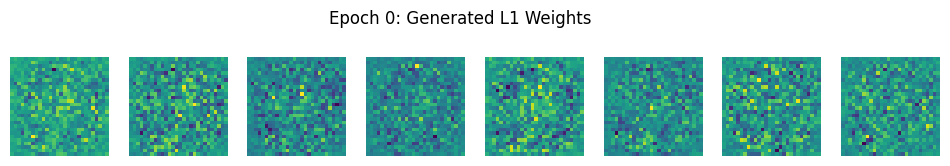

Epoch 1 | D Loss: -113.2973 | G Loss: 56.5808
Epoch 2 | D Loss: -183.2879 | G Loss: 92.6850
Epoch 3 | D Loss: -266.3266 | G Loss: 134.6443
Epoch 4 | D Loss: -357.2056 | G Loss: 182.2529
Epoch 5 | D Loss: -454.5039 | G Loss: 236.4493
Epoch 6 | D Loss: -559.2908 | G Loss: 294.3621
Epoch 7 | D Loss: -687.6948 | G Loss: 360.5691
Epoch 8 | D Loss: -798.9983 | G Loss: 431.0990
Epoch 9 | D Loss: -853.8160 | G Loss: 511.0777
Epoch 10 | D Loss: -917.8291 | G Loss: 589.8279


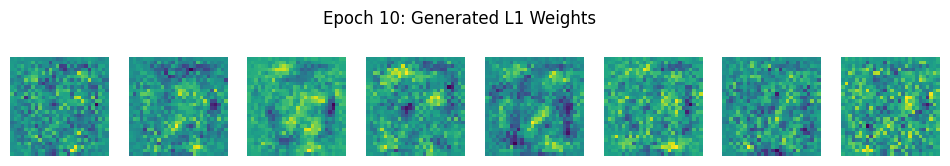

Epoch 11 | D Loss: -999.7562 | G Loss: 672.9542
Epoch 12 | D Loss: -1165.2023 | G Loss: 761.2640
Epoch 13 | D Loss: -1270.7100 | G Loss: 818.7141
Epoch 14 | D Loss: -1103.8713 | G Loss: 901.5199
Epoch 15 | D Loss: -891.6208 | G Loss: 913.3456
Epoch 16 | D Loss: -1157.5902 | G Loss: 1006.0382
Epoch 17 | D Loss: 306.2206 | G Loss: 260.4960
Epoch 18 | D Loss: -1509.5936 | G Loss: 1086.4896
Epoch 19 | D Loss: -1117.5052 | G Loss: 940.2911
Epoch 20 | D Loss: -1597.1050 | G Loss: 1140.7643


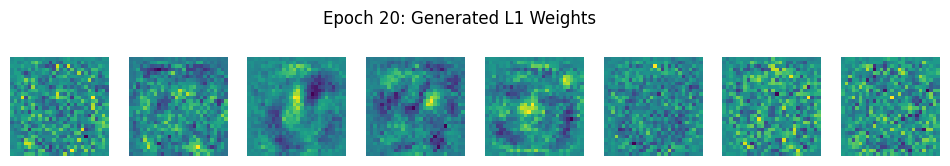

Epoch 21 | D Loss: -435.5738 | G Loss: 1190.4924
Epoch 22 | D Loss: -1543.3148 | G Loss: 1090.9504
Epoch 23 | D Loss: -981.0707 | G Loss: 1075.6003
Epoch 24 | D Loss: -858.1694 | G Loss: 1011.4869
Epoch 25 | D Loss: -877.9393 | G Loss: 970.0076
Epoch 26 | D Loss: -1277.7620 | G Loss: 1216.8716
Epoch 27 | D Loss: -874.0049 | G Loss: 1206.4261
Epoch 28 | D Loss: -1564.3508 | G Loss: 1266.5853
Epoch 29 | D Loss: -2011.3793 | G Loss: 1403.4341
Epoch 30 | D Loss: -1506.5422 | G Loss: 1219.7002


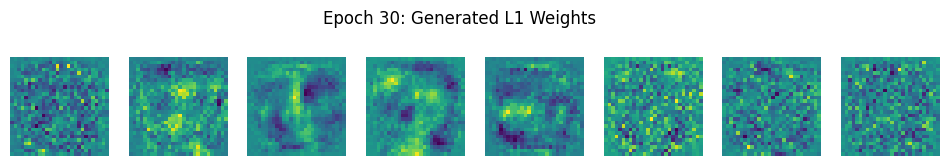

Epoch 31 | D Loss: -1436.9817 | G Loss: 1299.8218
Epoch 32 | D Loss: -375.3774 | G Loss: 978.2916
Epoch 33 | D Loss: -772.5598 | G Loss: 1179.8352
Epoch 34 | D Loss: -1758.6724 | G Loss: 1268.6904
Epoch 35 | D Loss: -938.4136 | G Loss: 283.7094
Epoch 36 | D Loss: -1229.9540 | G Loss: 1046.6602
Epoch 37 | D Loss: -1634.9094 | G Loss: 1086.3423
Epoch 38 | D Loss: -1540.1478 | G Loss: 1059.7997
Epoch 39 | D Loss: 1853.6244 | G Loss: -1266.2366
Epoch 40 | D Loss: -34.0140 | G Loss: 1000.6141


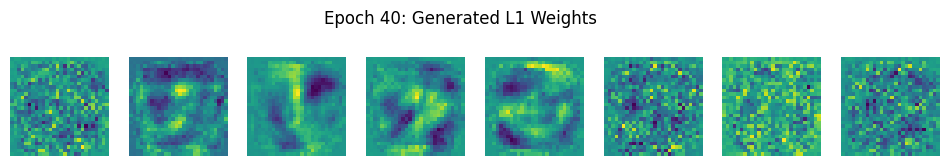

Epoch 41 | D Loss: -662.1104 | G Loss: 1411.3289
Epoch 42 | D Loss: -1647.3014 | G Loss: 1395.4631
Epoch 43 | D Loss: -1226.5669 | G Loss: 1388.7545
Epoch 44 | D Loss: -1107.6293 | G Loss: 1069.9221
Epoch 45 | D Loss: -257.2573 | G Loss: 1318.5520
Epoch 46 | D Loss: -1555.8484 | G Loss: 1168.3027
Epoch 47 | D Loss: -499.5089 | G Loss: 1644.5857
Epoch 48 | D Loss: -604.5249 | G Loss: 1000.6498
Epoch 49 | D Loss: -1105.2546 | G Loss: 1118.0593
Epoch 50 | D Loss: -601.6016 | G Loss: 785.9814


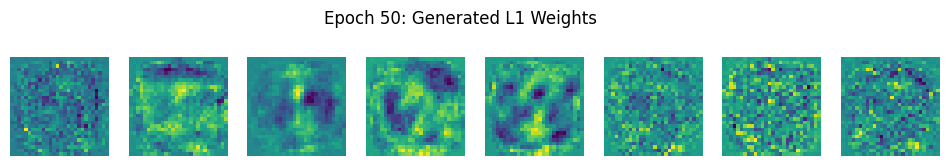

Epoch 51 | D Loss: -1144.0197 | G Loss: 985.6910
Epoch 52 | D Loss: -280.6805 | G Loss: 631.6920
Epoch 53 | D Loss: -1261.4014 | G Loss: 848.9996
Epoch 54 | D Loss: -942.7484 | G Loss: 892.6257
Epoch 55 | D Loss: -1111.5837 | G Loss: 823.0374
Epoch 56 | D Loss: -113.5796 | G Loss: 628.6584
Epoch 57 | D Loss: -430.3160 | G Loss: 779.0390
Epoch 58 | D Loss: -1430.5868 | G Loss: 788.9791
Epoch 59 | D Loss: -338.5493 | G Loss: 833.5306
Epoch 60 | D Loss: 1328.9275 | G Loss: 824.3009


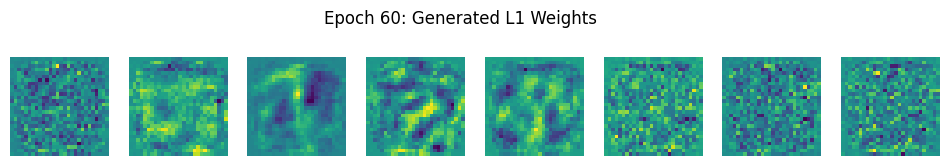

Epoch 61 | D Loss: -1218.9377 | G Loss: 803.5225
Epoch 62 | D Loss: -540.0383 | G Loss: 802.1689
Epoch 63 | D Loss: -226.5705 | G Loss: 208.7848
Epoch 64 | D Loss: 0.4745 | G Loss: 553.1334
Epoch 65 | D Loss: -326.8553 | G Loss: 257.6008
Epoch 66 | D Loss: -246.6561 | G Loss: 944.4860
Epoch 67 | D Loss: -599.7971 | G Loss: 560.7148


KeyboardInterrupt: 

In [9]:
# Training Loop (WGAN-GP) for Matrix/Set Representation
# Context: Generating sets of 256 neurons (each 785 dim)
import torch.autograd as autograd
import matplotlib.pyplot as plt
import numpy as np

# Optimizers
opt_gen = optim.Adam(gen.parameters(), lr=1e-4, betas=(0.5, 0.9))
opt_disc = optim.Adam(disc.parameters(), lr=1e-4, betas=(0.5, 0.9))

LAMBDA_GP = 10
n_epochs = 100
params_to_save = []

# Context manager for enabling math backend (needed for double backward in GP)
def get_attention_context():
    # Fallback to math-only kernel to ensure double-backward support (gradients of gradients)
    return torch.backends.cuda.sdp_kernel(enable_flash=False, enable_math=True, enable_mem_efficient=False)

def compute_gradient_penalty(D, real_samples, fake_samples):
    """Calculates the gradient penalty loss for WGAN GP"""
    # Random weight term for interpolation between real and fake samples
    alpha = torch.rand(real_samples.size(0), 1, 1).to(device)
    # Get random interpolation between real and fake samples
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    
    # Run Discriminator on interpolates
    with get_attention_context():
        d_interpolates = D(interpolates)
        
    fake = torch.ones(d_interpolates.shape, requires_grad=False).to(device)
    
    # Get gradient w.r.t. interpolates
    gradients = autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    
    # Flatten strictly for norm calculation
    gradients = gradients.reshape(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

# Validation / Visualization
def visualize_generated(generator, epoch):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(1, latent_dim).to(device)
        fake_seq = generator(z).cpu() # (1, 256, 785)
        
    # Un-standardize
    fake_data = fake_seq * sig_1.cpu() + mu_1.cpu()
    
    # Extract weights and biases
    # shape (1, 256, 785)
    # W: [:, :, :784], B: [:, :, 784]
    w_gen = fake_data[0, :, :784].numpy() # (256, 784)
    # b_gen = fake_data[0, :, 784].numpy()
    
    # Plot first 8 neurons as images (28x28)
    fig, axs = plt.subplots(1, 8, figsize=(12, 2))
    for i in range(8):
        img = w_gen[i].reshape(28, 28)
        axs[i].imshow(img, cmap='viridis')
        axs[i].axis('off')
    plt.suptitle(f"Epoch {epoch}: Generated L1 Weights")
    plt.show()
    generator.train()

print("Starting Training...")
for epoch in range(n_epochs):
    for i, (real_data,) in enumerate(loader_l1):
        real_data = real_data.to(device) # (B, 256, 785)
        batch_size = real_data.size(0)
        
        # --- Train Discriminator ---
        for _ in range(5):
            opt_disc.zero_grad()
            
            # Use math context
            with get_attention_context():
                # Real
                res_real = disc(real_data)
                d_real = res_real.mean()
                
                # Fake
                z = torch.randn(batch_size, latent_dim).to(device)
                fake_data = gen(z)
                res_fake = disc(fake_data.detach())
                d_fake = res_fake.mean()
            
            # GP (re-uses context internally)
            gp = compute_gradient_penalty(disc, real_data, fake_data.detach())
            
            loss_disc = d_fake - d_real + LAMBDA_GP * gp
            loss_disc.backward()
            opt_disc.step()
            
        # --- Train Generator ---
        opt_gen.zero_grad()
        z = torch.randn(batch_size, latent_dim).to(device)
        
        with get_attention_context():
            fake_data = gen(z)
            output = disc(fake_data)
            loss_gen = -output.mean()
        
        loss_gen.backward()
        opt_gen.step()
        
    print(f"Epoch {epoch} | D Loss: {loss_disc.item():.4f} | G Loss: {loss_gen.item():.4f}")
    
    if epoch % 10 == 0:
        visualize_generated(gen, epoch)


In [12]:
# Layer 2 GAN: Conditional Generation (L1 -> L2)
# L1: (256, 785) [Input]
# L2: (64, 257)  [Target]

# 1. Data Prep for Pairs
torch.cuda.empty_cache()
gc.collect()

# We already have L1 as X_layer1 (10000, 256, 785)
# Need to load/extract L2

# Scan offsets again for L2
l2_w_start, l2_w_end = -1, -1
l2_b_start, l2_b_end = -1, -1
current_idx = 0

for k in param_keys:
    shape = tuple(int(s) for s in param_shapes[k])
    numel = int(torch.tensor(shape).prod().item())
    
    if k == 'encoder.3.weight': # (64, 256)
        l2_w_start, l2_w_end = current_idx, current_idx + numel
    elif k == 'encoder.3.bias': # (64)
        l2_b_start, l2_b_end = current_idx, current_idx + numel
        
    current_idx += numel

# Exctract L2
W2 = weights_matrix[:, l2_w_start:l2_w_end] # (N, 16384)
B2 = weights_matrix[:, l2_b_start:l2_b_end] # (N, 64)

# Reshape and Stack
N = weights_matrix.shape[0]
W2 = W2.view(N, 64, 256)
B2 = B2.view(N, 64, 1)

X_layer2 = torch.cat([W2, B2], dim=2) # (N, 64, 257)
print(f"Layer 2 Matrix Shape: {X_layer2.shape}")

# Standardize L2
mu_2 = X_layer2.mean(dim=0, keepdim=True)
sig_2 = X_layer2.std(dim=0, keepdim=True) + 1e-6
X_layer2_std = (X_layer2 - mu_2) / sig_2

# Standardize L1 (Ensure we use the previous stats or re-calc)
# Since X_layer1 was already calculated in previous cell, we reuse it or re-calc if needed.
# Ideally we keep X_layer1_std from previous cells. 
# Re-verifying shape
print(f"Layer 1 Input Shape: {X_layer1_std.shape}")

# Dataset for Pairs
dataset_pairs = TensorDataset(X_layer1_std, X_layer2_std)
loader_pairs = DataLoader(dataset_pairs, batch_size=32, shuffle=True, drop_last=True)
print("Pair Loader Ready.")

# 2. Conditional Models via Transformer Encoder-Decoder

class ConditionalGenerator(nn.Module):
    def __init__(self, 
                 in_dim=785,    # L1 Feature Dim
                 out_dim=257,   # L2 Feature Dim
                 embed_dim=128, 
                 nhead=4, 
                 num_enc_layers=2, 
                 num_dec_layers=2, 
                 num_out_tokens=64): # L2 Neurons
        super().__init__()
        
        self.num_out_tokens = num_out_tokens
        
        # Encoder (Process L1)
        self.in_proj = nn.Linear(in_dim, embed_dim)
        self.pos_enc_l1 = nn.Parameter(torch.randn(1, 256, embed_dim) * 0.02) # Optional learned pos for input
        
        enc_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, dim_feedforward=embed_dim*2, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers, enable_nested_tensor=False)
        
        # Decoder (Generate L2 from L1)
        # Learnable queries for L2 neurons
        self.l2_queries = nn.Parameter(torch.randn(1, num_out_tokens, embed_dim))
        
        dec_layer = nn.TransformerDecoderLayer(d_model=embed_dim, nhead=nhead, dim_feedforward=embed_dim*2, batch_first=True, norm_first=True)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_dec_layers)
        
        # Output Head
        self.out_head = nn.Linear(embed_dim, out_dim)

    def forward(self, x_l1):
        # x_l1: (B, 256, 785)
        B = x_l1.size(0)
        
        # Encode L1
        src = self.in_proj(x_l1) + self.pos_enc_l1 # (B, 256, E)
        memory = self.encoder(src) # (B, 256, E)
        
        # Decode L2
        tgt = self.l2_queries.repeat(B, 1, 1) # (B, 64, E)
        
        # TransformerDecoder takes (tgt, memory)
        out_emb = self.decoder(tgt, memory) # (B, 64, E)
        
        # Project
        out = self.out_head(out_emb) # (B, 64, 257)
        return out

class ConditionalDiscriminator(nn.Module):
    def __init__(self, 
                 dim_l1=785, 
                 dim_l2=257, 
                 embed_dim=128, 
                 nhead=4, 
                 num_layers=2):
        super().__init__()
        
        # We will process BOTH L1 and L2 and see if they match.
        # Alternatively, just process L2 and condition on a pooled L1.
        # Let's concatenate them in a "siamese" ish way or just process L2 conditioned on L1?
        # Approach: Flatten/Pool both and concat.
        
        # Branch L1
        self.proj_l1 = nn.Linear(dim_l1, embed_dim)
        enc_l1 = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, batch_first=True, norm_first=True)
        self.body_l1 = nn.TransformerEncoder(enc_l1, num_layers=num_layers, enable_nested_tensor=False)
        
        # Branch L2
        self.proj_l2 = nn.Linear(dim_l2, embed_dim)
        enc_l2 = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, batch_first=True, norm_first=True)
        self.body_l2 = nn.TransformerEncoder(enc_l2, num_layers=num_layers, enable_nested_tensor=False)
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(embed_dim, 1)
        )
        
        # CLS Tokens
        self.cls_l1 = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.cls_l2 = nn.Parameter(torch.randn(1, 1, embed_dim))

    def forward(self, x_l1, x_l2):
        B = x_l1.size(0)
        
        # Process L1
        h1 = self.proj_l1(x_l1)
        h1 = torch.cat([self.cls_l1.repeat(B,1,1), h1], dim=1)
        h1 = self.body_l1(h1)
        feat_1 = h1[:, 0] # (B, E)
        
        # Process L2
        h2 = self.proj_l2(x_l2)
        h2 = torch.cat([self.cls_l2.repeat(B,1,1), h2], dim=1)
        h2 = self.body_l2(h2)
        feat_2 = h2[:, 0] # (B, E)
        
        # Combine
        combined = torch.cat([feat_1, feat_2], dim=1)
        return self.classifier(combined)

# Instantiate
gen_l2 = ConditionalGenerator().to(device)
disc_l2 = ConditionalDiscriminator().to(device)
print("Models Created.")


Layer 2 Matrix Shape: torch.Size([10000, 64, 257])
Layer 1 Input Shape: torch.Size([10000, 256, 785])
Pair Loader Ready.
Models Created.


Starting L2 Conditional Training...
Epoch 0 | D: -145.1637 | G_Adv: 144.8898 | G_MSE: 1.2271


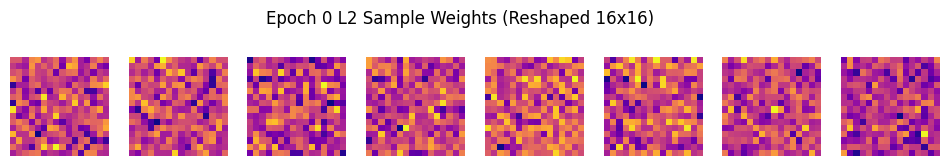

Epoch 1 | D: -144.9704 | G_Adv: 133.4834 | G_MSE: 1.1968
Epoch 2 | D: -172.6919 | G_Adv: 142.2523 | G_MSE: 1.2051
Epoch 3 | D: -157.6903 | G_Adv: 70.1890 | G_MSE: 1.2654
Epoch 4 | D: -187.0445 | G_Adv: 85.5982 | G_MSE: 1.2708
Epoch 5 | D: -152.5915 | G_Adv: 130.4211 | G_MSE: 1.3133
Epoch 6 | D: -189.8726 | G_Adv: 73.8943 | G_MSE: 1.1649
Epoch 7 | D: -201.2904 | G_Adv: 71.8464 | G_MSE: 1.2267
Epoch 8 | D: -254.4006 | G_Adv: 127.9264 | G_MSE: 1.1463
Epoch 9 | D: -207.4865 | G_Adv: 85.9537 | G_MSE: 1.1488
Epoch 10 | D: -265.4485 | G_Adv: 178.6705 | G_MSE: 1.1328


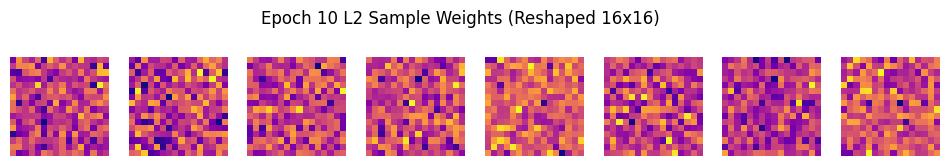

Epoch 11 | D: -244.6586 | G_Adv: 250.0126 | G_MSE: 1.0994
Epoch 12 | D: -235.8949 | G_Adv: 265.3863 | G_MSE: 1.1132
Epoch 13 | D: -282.6144 | G_Adv: 150.4380 | G_MSE: 1.1727
Epoch 14 | D: -308.7516 | G_Adv: 239.1265 | G_MSE: 1.1180
Epoch 15 | D: -235.3261 | G_Adv: 353.1647 | G_MSE: 1.0861
Epoch 16 | D: -239.4298 | G_Adv: 223.9196 | G_MSE: 1.1375
Epoch 17 | D: -277.1911 | G_Adv: 232.9161 | G_MSE: 1.1255
Epoch 18 | D: -274.3363 | G_Adv: 355.6108 | G_MSE: 1.1480
Epoch 19 | D: -240.7617 | G_Adv: 175.9880 | G_MSE: 1.1303
Epoch 20 | D: -234.1920 | G_Adv: 273.0042 | G_MSE: 1.1060


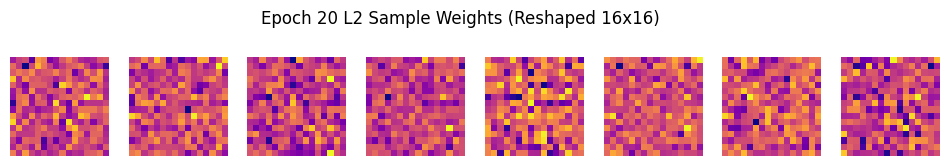

Epoch 21 | D: -245.0821 | G_Adv: 290.9330 | G_MSE: 1.1160
Epoch 22 | D: -297.3323 | G_Adv: 202.5984 | G_MSE: 1.1240
Epoch 23 | D: -259.0530 | G_Adv: 232.0286 | G_MSE: 1.0865
Epoch 24 | D: -271.0366 | G_Adv: 105.5122 | G_MSE: 1.1483
Epoch 25 | D: -222.0686 | G_Adv: 90.1044 | G_MSE: 1.0815
Epoch 26 | D: -243.7632 | G_Adv: 371.4261 | G_MSE: 1.0633
Epoch 27 | D: -192.1830 | G_Adv: 325.4392 | G_MSE: 1.2029
Epoch 28 | D: -277.1324 | G_Adv: 399.2060 | G_MSE: 1.1164
Epoch 29 | D: -182.0784 | G_Adv: 212.5390 | G_MSE: 1.0787
Epoch 30 | D: -261.0999 | G_Adv: 397.4109 | G_MSE: 1.1231


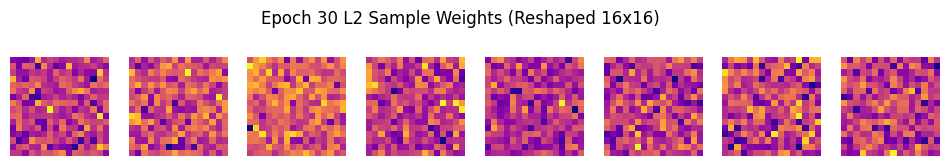

Epoch 31 | D: -174.1454 | G_Adv: 208.9693 | G_MSE: 1.1329
Epoch 32 | D: -231.5250 | G_Adv: 323.1464 | G_MSE: 1.1078
Epoch 33 | D: -207.1509 | G_Adv: 491.5251 | G_MSE: 1.0910
Epoch 34 | D: -301.9985 | G_Adv: 460.0616 | G_MSE: 1.1022
Epoch 35 | D: -262.4539 | G_Adv: 508.9092 | G_MSE: 1.1351
Epoch 36 | D: -296.3776 | G_Adv: 590.8841 | G_MSE: 1.1252
Epoch 37 | D: -229.3143 | G_Adv: 310.7901 | G_MSE: 1.1429
Epoch 38 | D: -272.8737 | G_Adv: 390.3838 | G_MSE: 1.1097
Epoch 39 | D: -197.0960 | G_Adv: 115.0472 | G_MSE: 1.1311
Epoch 40 | D: -223.3369 | G_Adv: 294.0121 | G_MSE: 1.1503


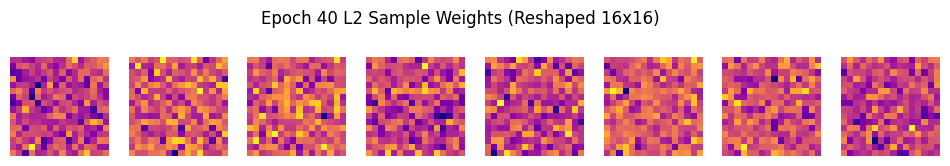

Epoch 41 | D: -273.3323 | G_Adv: 375.5500 | G_MSE: 1.1218
Epoch 42 | D: -253.7811 | G_Adv: 210.5193 | G_MSE: 1.1156
Epoch 43 | D: -282.8951 | G_Adv: 470.6812 | G_MSE: 1.1520
Epoch 44 | D: -242.5397 | G_Adv: 366.8295 | G_MSE: 1.1191
Epoch 45 | D: -252.8388 | G_Adv: 463.6704 | G_MSE: 1.1130
Epoch 46 | D: -235.5123 | G_Adv: 468.5733 | G_MSE: 1.1370
Epoch 47 | D: -177.4828 | G_Adv: 445.8141 | G_MSE: 1.1115
Epoch 48 | D: -196.0480 | G_Adv: 478.1953 | G_MSE: 1.1151
Epoch 49 | D: -226.5951 | G_Adv: 354.0848 | G_MSE: 1.1174
Epoch 50 | D: -197.2388 | G_Adv: 484.4865 | G_MSE: 1.1079


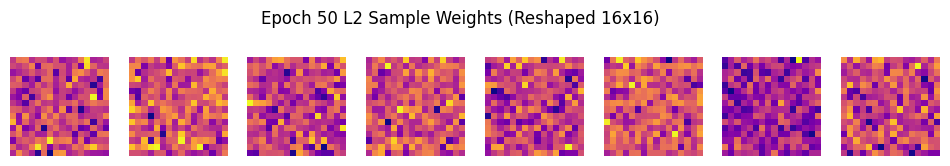

Epoch 51 | D: -208.4965 | G_Adv: 524.9546 | G_MSE: 1.1590
Epoch 52 | D: -190.2818 | G_Adv: 413.8000 | G_MSE: 1.1284
Epoch 53 | D: -205.2339 | G_Adv: 453.5171 | G_MSE: 1.1286
Epoch 54 | D: -266.7715 | G_Adv: 393.8503 | G_MSE: 1.1130
Epoch 55 | D: -234.1476 | G_Adv: 357.5233 | G_MSE: 1.1204
Epoch 56 | D: -180.6255 | G_Adv: 241.2974 | G_MSE: 1.1181
Epoch 57 | D: -318.5275 | G_Adv: 136.6729 | G_MSE: 1.1247
Epoch 58 | D: -266.9451 | G_Adv: 118.1533 | G_MSE: 1.1391


: 

In [ ]:
# Training Loop for Conditional Layer 2 GAN
# Objective: Generate L2 given L1.
# Loss: WGAN-GP + lambda * MSE

opt_gen_l2 = optim.Adam(gen_l2.parameters(), lr=1e-4, betas=(0.5, 0.9))
opt_disc_l2 = optim.Adam(disc_l2.parameters(), lr=1e-4, betas=(0.5, 0.9))

LAMBDA_GP = 10
LAMBDA_MSE = 100 # High weight for reconstruction constraint
n_epochs_l2 = 100

def compute_gp_conditional(D, real_l1, real_l2, fake_l2):
    # Interpolate only on the target (L2) space
    alpha = torch.rand(real_l2.size(0), 1, 1).to(device)
    interpolates = (alpha * real_l2 + ((1 - alpha) * fake_l2)).requires_grad_(True)
    
    # D takes (Condition, Target)
    with get_attention_context():
        d_interpolates = D(real_l1, interpolates)
        
    fake = torch.ones(d_interpolates.shape, requires_grad=False).to(device)
    
    gradients = autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    
    gradients = gradients.reshape(gradients.size(0), -1)
    gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gp

print("Starting L2 Conditional Training...")

for epoch in range(n_epochs_l2):
    for i, (r_l1, r_l2) in enumerate(loader_pairs):
        r_l1 = r_l1.to(device)
        r_l2 = r_l2.to(device)
        
        # --- Train Discriminator ---
        for _ in range(5):
            opt_disc_l2.zero_grad()
            
            with get_attention_context():
                # Real pair
                d_real = disc_l2(r_l1, r_l2).mean()
                
                # Fake pair
                # Condition on r_l1
                f_l2 = gen_l2(r_l1)
                d_fake = disc_l2(r_l1, f_l2.detach()).mean()
            
            gp = compute_gp_conditional(disc_l2, r_l1, r_l2, f_l2.detach())
            
            loss_d = d_fake - d_real + LAMBDA_GP * gp
            loss_d.backward()
            opt_disc_l2.step()
            
        # --- Train Generator ---
        opt_gen_l2.zero_grad()
        
        with get_attention_context(): # Gradients needed for G
            f_l2 = gen_l2(r_l1)
            
            # Adversarial Loss
            g_adv = -disc_l2(r_l1, f_l2).mean()
            
            # MSE Loss (Reconstruction)
            g_mse = nn.MSELoss()(f_l2, r_l2)
            
            loss_g = g_adv + LAMBDA_MSE * g_mse
            
        loss_g.backward()
        opt_gen_l2.step()
        
    print(f"Epoch {epoch} | D: {loss_d.item():.4f} | G_Adv: {g_adv.item():.4f} | G_MSE: {g_mse.item():.4f}")
    
    if epoch % 10 == 0:
        # Visualize one sample
        # L2 weights (64, 256). Let's reshape 256 -> 16x16
        with torch.no_grad():
            sample = f_l2[0, :8, :256].cpu().numpy() # First 8 neurons, weights only
            
        fig, axs = plt.subplots(1, 8, figsize=(12, 2))
        for i in range(8):
            img = sample[i].reshape(16, 16)
            axs[i].imshow(img, cmap='plasma')
            axs[i].axis('off')
        plt.suptitle(f"Epoch {epoch} L2 Sample Weights (Reshaped 16x16)")
        plt.show()

Filtered keys: 12 Missing in load: 0 Skipped (shape/name mismatch): 0
Model loaded with inferred latent_dim = 8


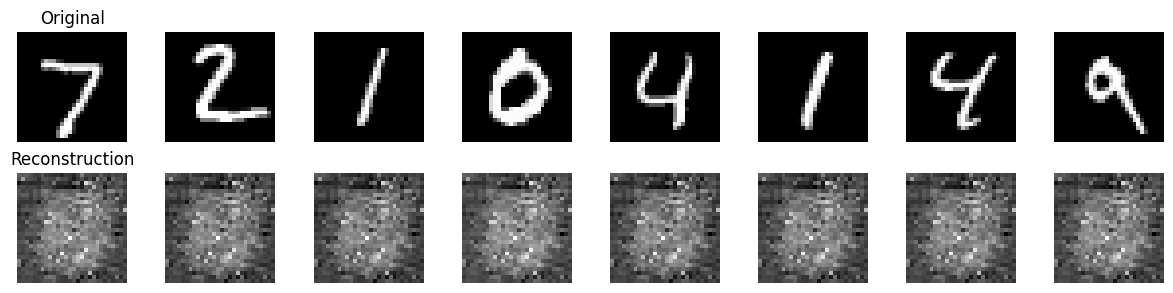

Batch MSE (8 samples): 0.151306


In [ ]:
# Load Meta-AE reconstructed weights and visualize
import math
import torch
import matplotlib.pyplot as plt

# Check requirements
assert 'param_keys' in globals() and 'param_shapes' in globals()

ws_path = ckpt_dir / 'generated_weights_meta_ae.pt'
if not ws_path.exists():
    # Fallback if user didn't run the above cell or filenames differ
    ws_path = ckpt_dir / 'generated_weights_wgan_fulldim.pt'

print(f"Loading weights from: {ws_path}")
payload = torch.load(ws_path, map_location='cpu')
Xg = payload['generated_full']  # (n_samples, D_full)
mu_fd = payload.get('mu', None) # Might need if we were generating from scratch

# Target full length
D_full = sum(int(math.prod(param_shapes[k])) for k in param_keys)
vec = Xg[0].view(-1)
Dc = vec.numel()

# Handle potential size mismatch (padding/cropping) if Meta-AE worked on reduced dims
if Dc < D_full and mu_fd is not None:
    pad_tail = mu_fd[Dc:D_full]
    vec_full = torch.cat([vec, pad_tail], dim=0)
elif Dc > D_full:
    vec_full = vec[:D_full]
else:
    vec_full = vec

# Rebuild state dict
state_gen = {}
off = 0
for k in param_keys:
    shape = tuple(int(s) for s in param_shapes[k])
    sz = int(math.prod(shape))
    chunk = vec_full[off:off+sz].reshape(shape)
    state_gen[k] = chunk.clone()
    off += sz

# Inferred latent dim
enc_out_dims = []
for k, shape in param_shapes.items():
    if ('encoder' in k) and isinstance(shape, (list, tuple)) and len(shape) == 2:
        enc_out_dims.append(int(shape[0]))
latent_guess = min(enc_out_dims) if enc_out_dims else 8

# Instantiate and Load
model_gen = Autoencoder(latent_dim=latent_guess).to(device)
model_state = model_gen.state_dict()
filtered = {}
for k, v in state_gen.items():
    if k in model_state and tuple(model_state[k].shape) == tuple(v.shape):
        filtered[k] = v

model_gen.load_state_dict({**model_state, **filtered}, strict=False)
model_gen.eval()

# Reconstruct
with torch.no_grad():
    imgs, _ = next(iter(test_loader))
    imgs = imgs.to(device)
    rec = model_gen(imgs[:8])

# Visualize
rows = 2
fig, axes = plt.subplots(rows, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(imgs[i, 0].detach().cpu().numpy(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(rec[i, 0].detach().cpu().numpy(), cmap='gray')
    axes[1, i].axis('off')
axes[0,0].set_title('Original')
axes[1,0].set_title('Meta-AE Recon')
plt.tight_layout()
plt.show()

mse = torch.mean((imgs[:8] - rec[:8])**2).item()
print(f"Reconstruction MSE: {mse:.4f}")